# EDA Art Dataset

In [1]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
root_dir = "../data/art/fake"
base_dir = "../data_resized/art"
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

class_prefixes = ["AI_DiffusionDB", "AI_LD", "AI_SD"]

### Helpers functions

In [3]:
def count_images(directory: str, recursive: bool = True) -> int:
    """
    Counts the number of image files in the given directory.

    Args:
        directory (str): The root directory path.
        recursive (bool): If True, search subdirectories as well.

    Returns:
        int: Number of image files found.
    """
    image_extensions = {'.jpg', '.jpeg', '.png',
                        '.gif', '.bmp', '.tiff', '.webp'}
    path = Path(directory)

    if recursive:
        files = path.rglob("*")
    else:
        files = path.glob("*")

    return sum(1 for file in files if file.suffix.lower() in image_extensions)


def format_size(size_bytes: int) -> str:
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if size_bytes < 1024:
            return f"{size_bytes:.2f} {unit}"
        size_bytes /= 1024
    return f"{size_bytes:.2f} PB"


def get_folder_size(directory: str, recursive: bool = True) -> int:
    """
    Returns the total size of all files in a directory.

    Args:
        directory (str): The directory path.
        recursive (bool): If True, include subdirectories.

    Returns:
        int: Total size in bytes.
    """
    path = Path(directory)

    if recursive:
        files = path.rglob("*")
    else:
        files = path.glob("*")

    return format_size(sum(f.stat().st_size for f in files if f.is_file()))


def compute_brightness(image_path):
    """Compute average brightness of an image."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

## EDA

### Class count

In [4]:
count_fake = count_images("../data_resized/art/fake")
count_real = count_images("../data_resized/art/real")

print(f"\nTotal images in fake directory: {count_fake}")
print(f"Total images in real directory: {count_real}")

print(f"Percentage of fake images: {count_fake / (count_fake + count_real) * 100:.2f}%")
print(f"Percentage of real images: {count_real / (count_fake + count_real) * 100:.2f}%")


Total images in fake directory: 59465
Total images in real directory: 48259
Percentage of fake images: 55.20%
Percentage of real images: 44.80%


### Comparison size of dataset before and after resizing

In [5]:
size_bytes_original = get_folder_size("../data/art/")
size_bytes_resized = get_folder_size(base_dir)

print(f"\nOriginal folder size: {size_bytes_original}")
print(f"Resized folder size: {size_bytes_resized}")


Original folder size: 20.32 GB
Resized folder size: 2.37 GB


### Diffusion model analysis

In [6]:
image_counts = defaultdict(int)

for subfolder in os.listdir(root_dir):
    subfolder_path = os.path.join(root_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    matched_class = next(
        (prefix for prefix in class_prefixes if subfolder.startswith(prefix)), None)
    if matched_class:

        for file in os.listdir(subfolder_path):
            if os.path.splitext(file)[1].lower() in valid_extensions:
                image_counts[matched_class] += 1
    
# create a table with the counts
df = pd.DataFrame(list(image_counts.items()), columns=["Class", "Count"])

# display the table
print("\nImage counts by class:")
print(df)



Image counts by class:
            Class  Count
0           AI_LD  31922
1  AI_DiffusionDB  21292
2           AI_SD   6251


TODO: Plot a histogram with all diffusion model from 3 datasets

### Brightness analysis

In [7]:
fake_dir = os.path.join(base_dir, "fake")
real_dir = os.path.join(base_dir, "real")

brightness_fake = []
brightness_real = []

for filename in tqdm(os.listdir(fake_dir), desc="Processing fake images"):
    path = os.path.join(fake_dir, filename)
    brightness = compute_brightness(path)
    if brightness is not None:
        brightness_fake.append(brightness)

for filename in tqdm(os.listdir(real_dir), desc="Processing real images"):
    path = os.path.join(real_dir, filename)
    brightness = compute_brightness(path)
    if brightness is not None:
        brightness_real.append(brightness)



Processing real images: 100%|██████████| 48259/48259 [00:27<00:00, 1766.94it/s]


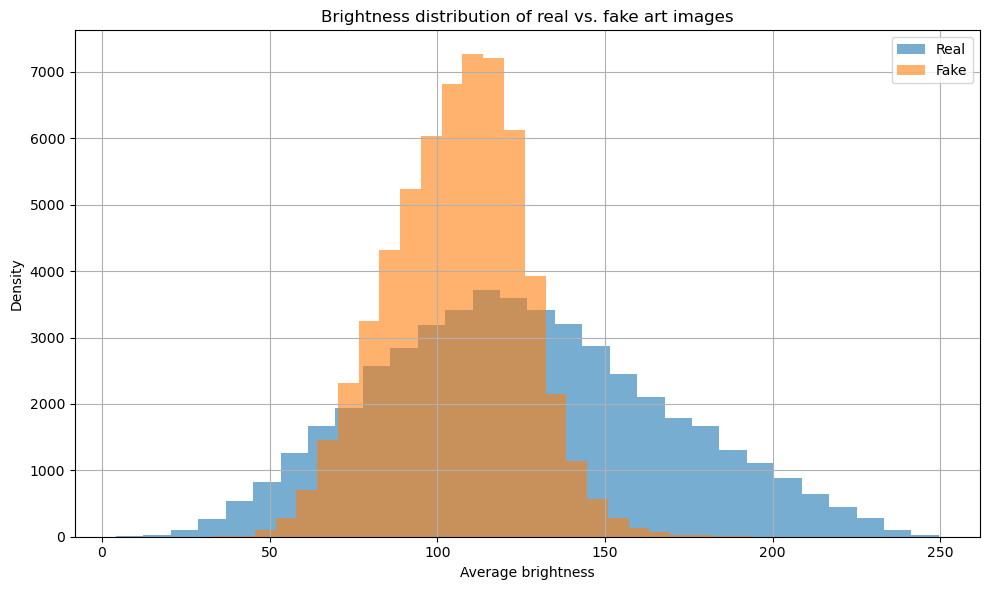

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(brightness_real, bins=30, alpha=0.6, label='Real')
plt.hist(brightness_fake, bins=30, alpha=0.6, label='Fake')
plt.xlabel("Average brightness")
plt.ylabel("Density")
plt.title("Brightness distribution of real vs. fake art images")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cluster analysis

In [5]:
def load_images_from_dir(directory, label, target_size=(200, 200), max_images=5000):
    images = []
    labels = []
    count = 0
    for fname in tqdm(os.listdir(directory), desc=f"Loading {label}"):
        if count >= max_images:
            break
        try:
            path = os.path.join(directory, fname)
            img = load_img(path, target_size=target_size)
            img_array = img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(label)
            count += 1
        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue
    return np.array(images), np.array(labels)


# load 5,000 images only otherwise it takes too much memory
max_images = 5000
real_dir = "../data_resized/art/real"
fake_dir = "../data_resized/art/fake"
X_real, y_real = load_images_from_dir(real_dir, 0, max_images=max_images // 2)
X_fake, y_fake = load_images_from_dir(fake_dir, 1, max_images=max_images // 2)

X = np.concatenate([X_real, X_fake])
y = np.concatenate([y_real, y_fake])

# extract features
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
features = model.predict(X, batch_size=32, verbose=1)

# t-SNE
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_3d = tsne.fit_transform(features)

# KMeans cluster
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_3d)


Loading 1:   4%|▍         | 2500/59465 [00:01<00:38, 1487.82it/s]


157/157 ━━━━━━━━━━━━━━━━━━━━ 110s 688ms/step


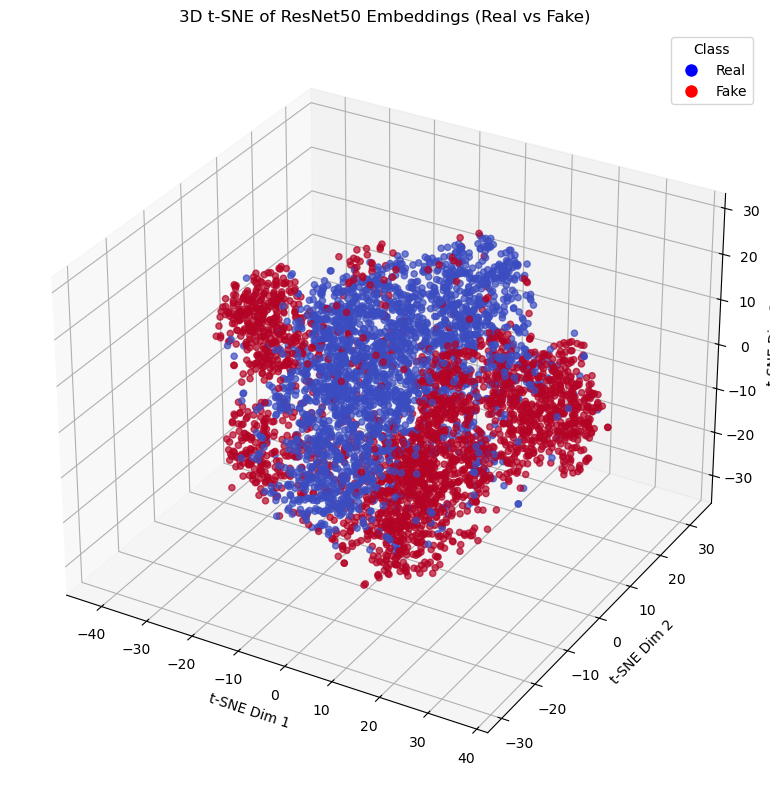

In [6]:

fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                     c=y, cmap='coolwarm', marker='o', alpha=0.7)

ax.set_title("3D t-SNE of ResNet50 Embeddings (Real vs Fake)")
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.set_zlabel("t-SNE Dim 3")

legend_labels = ['Real', 'Fake']
legend_colors = [plt.Line2D([0], [0], marker='o', color='w', label=lbl,
                            markerfacecolor=col, markersize=10)
                 for lbl, col in zip(legend_labels, ['blue', 'red'])]
ax.legend(handles=legend_colors, title="Class")

plt.tight_layout()
plt.show()

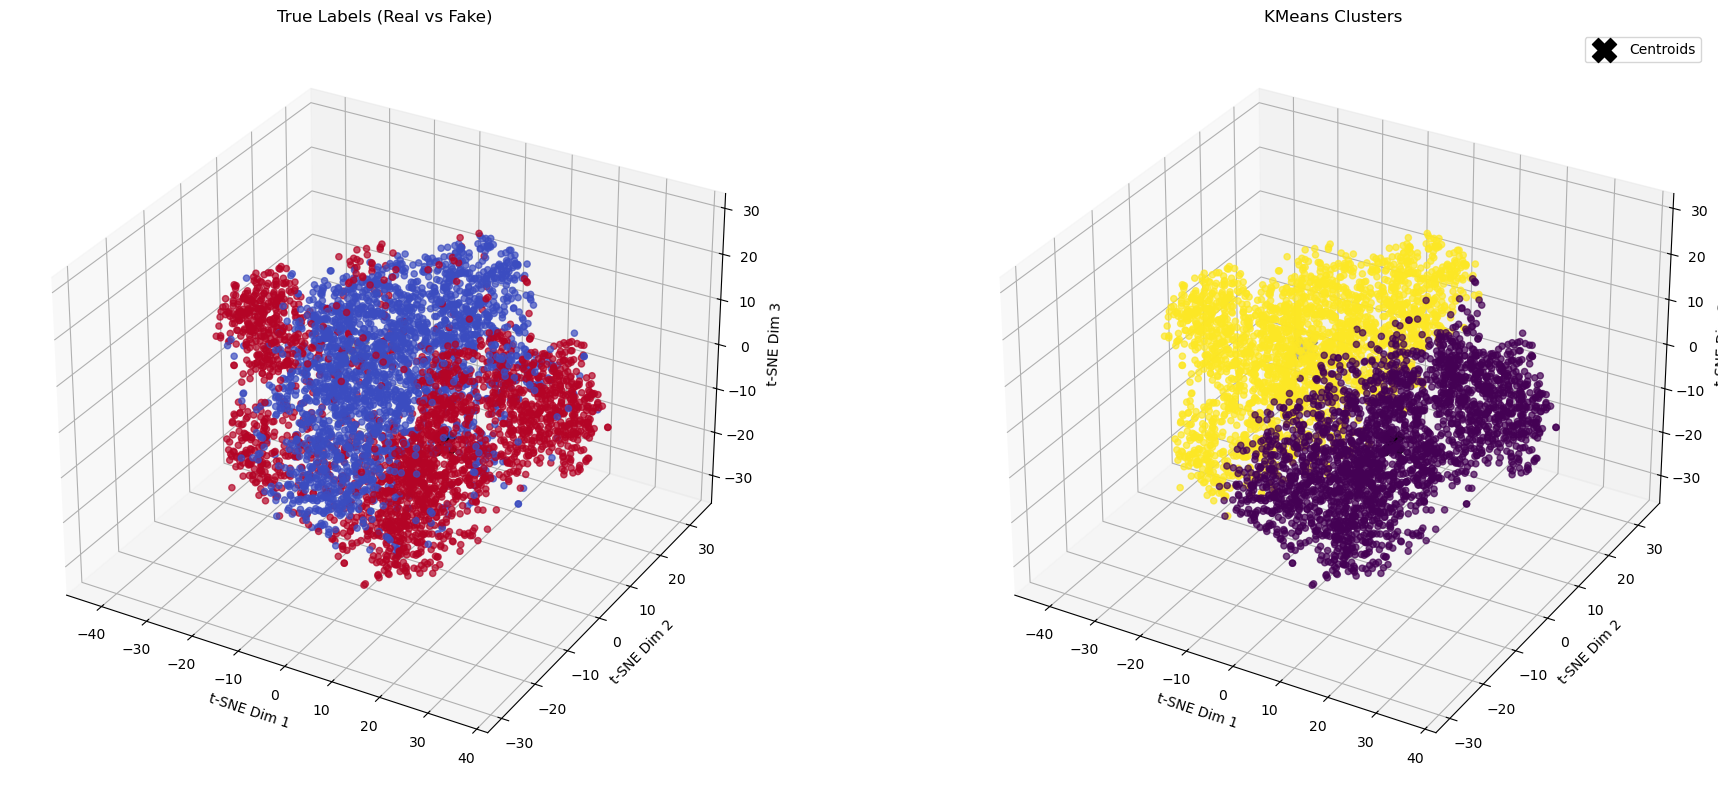

In [ ]:
fig = plt.figure(figsize=(20, 8))
centroids = kmeans.cluster_centers_

# Plot true labels
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
            c=y, cmap='coolwarm', alpha=0.7)
ax1.set_title("True Labels (Real vs Fake)")
ax1.set_xlabel("t-SNE Dim 1")
ax1.set_ylabel("t-SNE Dim 2")
ax1.set_zlabel("t-SNE Dim 3")

# Plot predicted clusters
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
            c=clusters, cmap='viridis', alpha=0.7)
ax2.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            s=300, c='black', marker='X', label='Centroids')
ax2.set_title("KMeans Clusters")
ax2.set_xlabel("t-SNE Dim 1")
ax2.set_ylabel("t-SNE Dim 2")
ax2.set_zlabel("t-SNE Dim 3")


ax2.legend()
plt.tight_layout()
plt.show()